In [ ]:
# Remove preinstalled/conflicting wheels to avoid NumPy/TF ABI mismatch
!pip -q uninstall -y tensorflow tensorflow-text tf-keras keras keras-core keras-nlp \
  numpy protobuf jax jaxlib ml-dtypes numba tensorflow-decision-forests ydf tensorstore \
  thinc opentelemetry-proto grpcio-status || true


In [ ]:
!pip -q install "numpy==2.1.3" "protobuf==5.29.1"
!pip -q install "tensorflow==2.19.0" "tf-keras==2.19.0" "tensorflow-text==2.19.0"
!pip -q install "nltk==3.9.1"


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
chex 0.1.90 requires jax>=0.4.27, which is not installed.
chex 0.1.90 requires jaxlib>=0.4.27, which is not installed.
flax 0.10.7 requires jax>=0.6.0, which is not installed.
flax 0.10.7 requires tensorstore, which is not installed.
optax 0.2.6 requires jax>=0.5.3, which is not installed.
optax 0.2.6 requires jaxlib>=0.5.3, which is not installed.
librosa 0.11.0 requires numba>=0.51.0, which is not installed.
shap 0.49.1 requires numba>=0.54, which is not installed.
umap-learn 0.5.9.post2 requires numba>=0.51.2, which is not installed.
cudf-cu12 25.6.0 requires numba<0.62.0a0,>=0.59.1, which is not installed.
spacy 3.8.7 requires thinc<8.4.0,>=8.3.4, which is not installed.
stumpy 1.13.0 requires numba>=0.57.1, which is not installed.
tensorflow-hub 0.16.1 requires tf-keras>=2.14.1, which is not installed.
dask-c

In [ ]:
!pip install --force-reinstall --no-cache-dir "tensorflow==2.19.0" "tf-keras==2.19.0" "tensorflow-text==2.19.0"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 166.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 144.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 153.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 197.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 235.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 242.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 84.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 238.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 160.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 239.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 175.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.9/71

In [ ]:
import tensorflow as tf, numpy as np, sys
print("✅ TensorFlow version:", tf.__version__)
print("✅ NumPy version:", np.__version__)
print("Python:", sys.version)
print("GPU:", tf.config.list_physical_devices('GPU'))


✅ TensorFlow version: 2.19.0
✅ NumPy version: 2.1.3
Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
GPU: []


In [ ]:
from tensorflow.keras import Sequential, layers
m = Sequential([layers.Input((4,)), layers.Dense(3, activation='relu'), layers.Dense(1)])
m.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 3)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19 (76.00 B)

 Trainable params: 19 (76.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import numpy as np, tensorflow as tf, nltk, sys
print("NumPy:", np.__version__)
print("TensorFlow:", tf.__version__)
print("Python:", sys.version)
print("GPU:", tf.config.list_physical_devices('GPU'))



NumPy: 2.1.3
TensorFlow: 2.19.0
Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
GPU: []


In [ ]:
import os, random, re, math, json, sys
import numpy as np
import tensorflow as tf

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print("TF version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TF version: 2.19.0
GPU available: []


In [ ]:
import nltk
nltk.download('gutenberg')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import gutenberg

# Use three Jane Austen books
files = ['austen-emma.txt', 'austen-persuasion.txt', 'austen-sense.txt']
raw_texts = [gutenberg.raw(f) for f in files]
print("Loaded files:", files)
print("Total characters:", sum(len(t) for t in raw_texts))


[nltk_data] Downloading package gutenberg to /root/nltk_data...
[nltk_data]   Unzipping corpora/gutenberg.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Loaded files: ['austen-emma.txt', 'austen-persuasion.txt', 'austen-sense.txt']
Total characters: 2026385


In [ ]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def clean_text(txt):
    txt = txt.lower()
    txt = re.sub(r"[^a-z0-9'.,;:!?()\-\s]", " ", txt)
    txt = re.sub(r"\s+", " ", txt).strip()
    return txt

def tokenize_and_lemmatize(txt):
    tokens = txt.split()
    tokens = [lemmatizer.lemmatize(tok) for tok in tokens]
    return tokens

corpus_text = " ".join(clean_text(t) for t in raw_texts)
tokens = tokenize_and_lemmatize(corpus_text)

print("Total tokens (after cleaning):", len(tokens))
print("Sample:", tokens[:40])


Total tokens (after cleaning): 360559
Sample: ['emma', 'by', 'jane', 'austen', '1816', 'volume', 'i', 'chapter', 'i', 'emma', 'woodhouse,', 'handsome,', 'clever,', 'and', 'rich,', 'with', 'a', 'comfortable', 'home', 'and', 'happy', 'disposition,', 'seemed', 'to', 'unite', 'some', 'of', 'the', 'best', 'blessing', 'of', 'existence;', 'and', 'had', 'lived', 'nearly', 'twenty-one', 'year', 'in', 'the']


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

VOCAB_SIZE = 20000  # cap vocab; adjust if needed
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts([" ".join(tokens)])

seq_ids = tokenizer.texts_to_sequences([" ".join(tokens)])[0]
word_index = tokenizer.word_index
index_word = {v:k for k,v in word_index.items()}

actual_vocab = min(VOCAB_SIZE if VOCAB_SIZE else len(word_index)+1, len(word_index)+1)
print("Vocab size (used):", actual_vocab)
print("First 20 ids:", seq_ids[:20])


Vocab size (used): 10300
First 20 ids: [70, 33, 170, 4447, 6631, 2389, 7, 347, 7, 70, 178, 511, 909, 4, 844, 21, 6, 539, 171, 4]


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

SEQ_LEN = 20  # context length

X, y = [], []
for i in range(SEQ_LEN, len(seq_ids)):
    X.append(seq_ids[i-SEQ_LEN:i])
    y.append(seq_ids[i])

X = np.array(X, dtype=np.int32)
y = np.array(y, dtype=np.int32)

print("X shape:", X.shape, "| y shape:", y.shape)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.1, random_state=SEED, shuffle=True
)
print("Train:", X_train.shape, "Val:", X_val.shape)


X shape: (364765, 20) | y shape: (364765,)
Train: (328288, 20) Val: (36477, 20)


In [ ]:
from tensorflow.keras import layers, models

EMBED_DIM = 128
LSTM_UNITS = 256
DROPOUT = 0.2

inputs = layers.Input(shape=(SEQ_LEN,))
x = layers.Embedding(input_dim=actual_vocab, output_dim=EMBED_DIM, input_length=SEQ_LEN)(inputs)
x = layers.Bidirectional(layers.LSTM(LSTM_UNITS, return_sequences=False))(x)
x = layers.Dropout(DROPOUT)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(DROPOUT)(x)
outputs = layers.Dense(actual_vocab, activation='softmax')(x)

model = models.Model(inputs, outputs)
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    metrics=['accuracy']
)
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 20, 128)        │     1,318,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 512)            │       788,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10300)          │     2,647,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,885,308 (18.64 MB)

 Trainable params: 4,885,308 (18.64 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

CKPT_PATH = "bilstm_gutenberg_nextword.keras"

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint(CKPT_PATH, monitor='val_loss', save_best_only=True)
]

BATCH_SIZE = 256
EPOCHS = 15

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/15
1283/1283 ━━━━━━━━━━━━━━━━━━━━ 1108s 860ms/step - accuracy: 0.0481 - loss: 6.3155 - val_accuracy: 0.0696 - val_loss: 6.0126
Epoch 2/15
1283/1283 ━━━━━━━━━━━━━━━━━━━━ 1091s 851ms/step - accuracy: 0.0812 - loss: 5.8740 - val_accuracy: 0.0960 - val_loss: 5.7687
Epoch 3/15
1283/1283 ━━━━━━━━━━━━━━━━━━━━ 1067s 832ms/step - accuracy: 0.1061 - loss: 5.5862 - val_accuracy: 0.1143 - val_loss: 5.5519
Epoch 4/15
1283/1283 ━━━━━━━━━━━━━━━━━━━━ 1098s 829ms/step - accuracy: 0.1207 - loss: 5.3778 - val_accuracy: 0.1246 - val_loss: 5.4513
Epoch 5/15
1283/1283 ━━━━━━━━━━━━━━━━━━━━ 1065s 830ms/step - accuracy: 0.1289 - loss: 5.2392 - val_accuracy: 0.1304 - val_loss: 5.3985
Epoch 6/15
1283/1283 ━━━━━━━━━━━━━━━━━━━━ 1059s 826ms/step - accuracy: 0.1354 - loss: 5.1290 - val_accuracy: 0.1344 - val_loss: 5.3670
Epoch 7/15
1283/1283 ━━━━━━━━━━━━━━━━━━━━ 1117s 838ms/step - accuracy: 0.1407 - loss: 5.0306 - val_accuracy: 0.1374 - val_loss: 5.3583
Epoch 8/15
1283/1283 ━━━━━━━━━━━━━━━━━━━━ 1067s 832ms/s

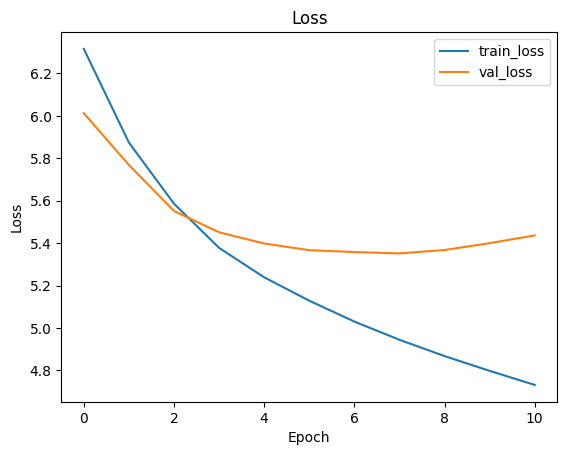

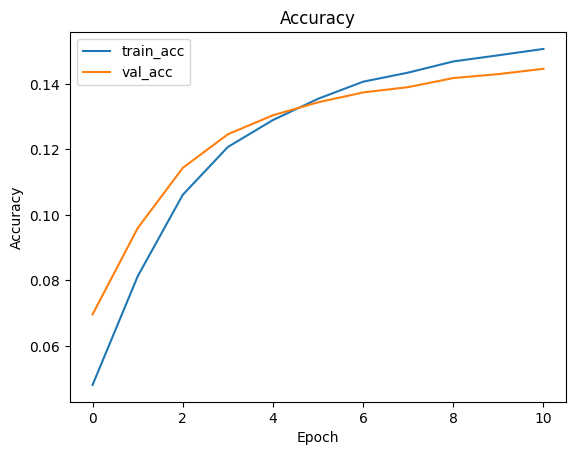

In [11]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.legend()
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.show()

plt.figure()
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.legend()
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.show()


In [12]:
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
perplexity = math.exp(val_loss)
print(f"Validation loss: {val_loss:.4f}")
print(f"Validation accuracy: {val_acc:.4f}")
print(f"Validation perplexity: {perplexity:.2f}")


Validation loss: 5.3519
Validation accuracy: 0.1390
Validation perplexity: 211.01


In [13]:
def generate_text(seed_text, num_words=30, temperature=1.0):
    """
    Temperature sampling for next-word generation.
    """
    text = clean_text(seed_text.lower())
    toks = tokenize_and_lemmatize(text).copy()

    for _ in range(num_words):
        last_tokens = toks[-SEQ_LEN:]
        seq = tokenizer.texts_to_sequences([" ".join(last_tokens)])[0]
        seq = [0]*(SEQ_LEN - len(seq)) + seq if len(seq) < SEQ_LEN else seq[-SEQ_LEN:]
        seq = np.array([seq], dtype=np.int32)

        preds = model.predict(seq, verbose=0)[0]
        if temperature != 1.0:
            logits = np.log(np.maximum(preds, 1e-9)) / temperature
            probs = np.exp(logits) / np.sum(np.exp(logits))
            next_id = np.random.choice(len(probs), p=probs)
        else:
            next_id = np.argmax(preds)

        next_word = index_word.get(next_id, None)
        if (next_word is None) or (next_word == "<OOV>"):
            next_word = "the"
        toks.append(next_word)

    return " ".join(toks)

print(generate_text("She had never seen such a", num_words=25, temperature=0.9))


she had never seen such a part which which would not be a frederick visit mr weston failed his good one wa that mr woodhouse wa perfectly so much in it


In [ ]:
import pickle

with open("tokenizer_gutenberg.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

model.save("bilstm_gutenberg_nextword_final.keras")

# How to load later:
# from tensorflow.keras.models import load_model
# with open("tokenizer_gutenberg.pkl", "rb") as f:
#     tokenizer = pickle.load(f)
# model = load_model("bilstm_gutenberg_nextword_final.keras")


In [ ]:
# Try smaller context or model if you need faster runs:
# SEQ_LEN = 15
# EMBED_DIM = 96
# LSTM_UNITS = 128
# (If you change SEQ_LEN, rebuild X/y and the model.)
